HOUSE PRICE PREDICTION

Objective:
The objective of this project is to predict house prices based on various property features such as area, bedrooms, bathrooms, parking availability, furnishing status, and other amenities.

Machine Learning models used:
  1. Linear Regression
  2. Random Forest Regressor

Evaluation Metrics:
    - MAE
    - RMSE
    - R² Score


TASK1:DATA LOADING & EXPLORATION


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
print("First 10 Rows of Dataset:")
df.head(10)

First 10 Rows of Dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape:
(545, 13)

Number of Rows: 545
Number of Columns: 13


In [6]:
target = "price"

features = df.drop(columns=[target]).columns

print("Target Column:")
print(target)

print("\nFeature Columns:")
print(list(features))

Target Column:
price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [7]:
print("Data Types:")
print(df.dtypes)

Data Types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [8]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [9]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [10]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [11]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


mainroad:
['yes' 'no']

guestroom:
['no' 'yes']

basement:
['no' 'yes']

hotwaterheating:
['no' 'yes']

airconditioning:
['yes' 'no']

prefarea:
['yes' 'no']

furnishingstatus:
['furnished' 'semi-furnished' 'unfurnished']


TASK2:DATA CLEANING

In [12]:
df_clean = df.copy()

In [13]:
# Check missing values before cleaning
print("Missing Values Before Cleaning:")
print(df_clean.isnull().sum())

# Numerical columns → fill with median
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns → fill with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

Missing Values Before Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Missing Values After Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [14]:
#check and rempve duplicates
print("Number of Duplicate Rows Before Removal:")
print(df_clean.duplicated().sum())

# Remove duplicates
df_clean.drop_duplicates(inplace=True)

print("\nNumber of Duplicate Rows After Removal:")
print(df_clean.duplicated().sum())

Number of Duplicate Rows Before Removal:
0

Number of Duplicate Rows After Removal:
0


In [15]:
print("Categorical Columns:")
print(df_clean.select_dtypes(include='object').columns)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [16]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=['mainroad',
             'guestroom',
             'basement',
             'hotwaterheating',
             'airconditioning',
             'prefarea',
             'furnishingstatus'],
    drop_first=True
)

print("Dataset Shape After Encoding:")
print(df_encoded.shape)

Dataset Shape After Encoding:
(545, 14)


In [17]:
print("Final Columns Used for Prediction:\n")

for col in df_encoded.columns:
    print(col)

Final Columns Used for Prediction:

price
area
bedrooms
bathrooms
stories
parking
mainroad_yes
guestroom_yes
basement_yes
hotwaterheating_yes
airconditioning_yes
prefarea_yes
furnishingstatus_semi-furnished
furnishingstatus_unfurnished


In [18]:
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [19]:
print("Final Dataset Shape:")
print(df_encoded.shape)

print("\nFirst 5 Rows:")
df_encoded.head()

Final Dataset Shape:
(545, 14)

First 5 Rows:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


TASK3:MODEL BUILDING

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [21]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


The dataset is split into 80% training data and 20% testing data to evaluate model performance on unseen data.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:")
print(X_train.shape)

print("\nTesting Set Shape:")
print(X_test.shape)

Training Set Shape:
(436, 13)

Testing Set Shape:
(109, 13)


In [23]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [24]:
lr_predictions = lr_model.predict(X_test)

print("First 5 Predictions:")
print(lr_predictions[:5])

First 5 Predictions:
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


In [25]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-"*30)

print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
------------------------------
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


In [26]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [27]:
rf_predictions = rf_model.predict(X_test)

print("First 5 Predictions:")
print(rf_predictions[:5])

First 5 Predictions:
[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [28]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("-"*30)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
------------------------------
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [29]:
comparison = {
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


Model Comparison

Linear Regression achieved a higher R² score and lower error values compared to Random Forest.

This suggests that the relationship between housing features and price is relatively linear in this dataset.

Therefore, Linear Regression is selected as the final model.

In [30]:
if rf_r2 > lr_r2:
    print("Random Forest performed better.")
else:
    print("Linear Regression performed better.")

Linear Regression performed better.


TASK4:VISUALIZATION & SUMMARY

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

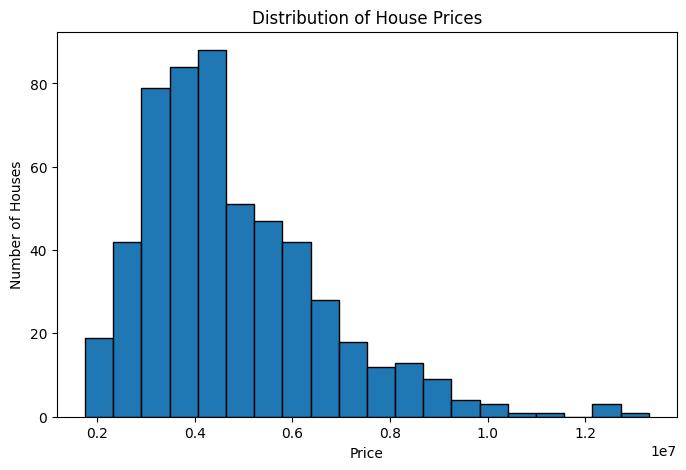

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df['price'],
         bins=20,
         edgecolor='black')

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')

plt.show()

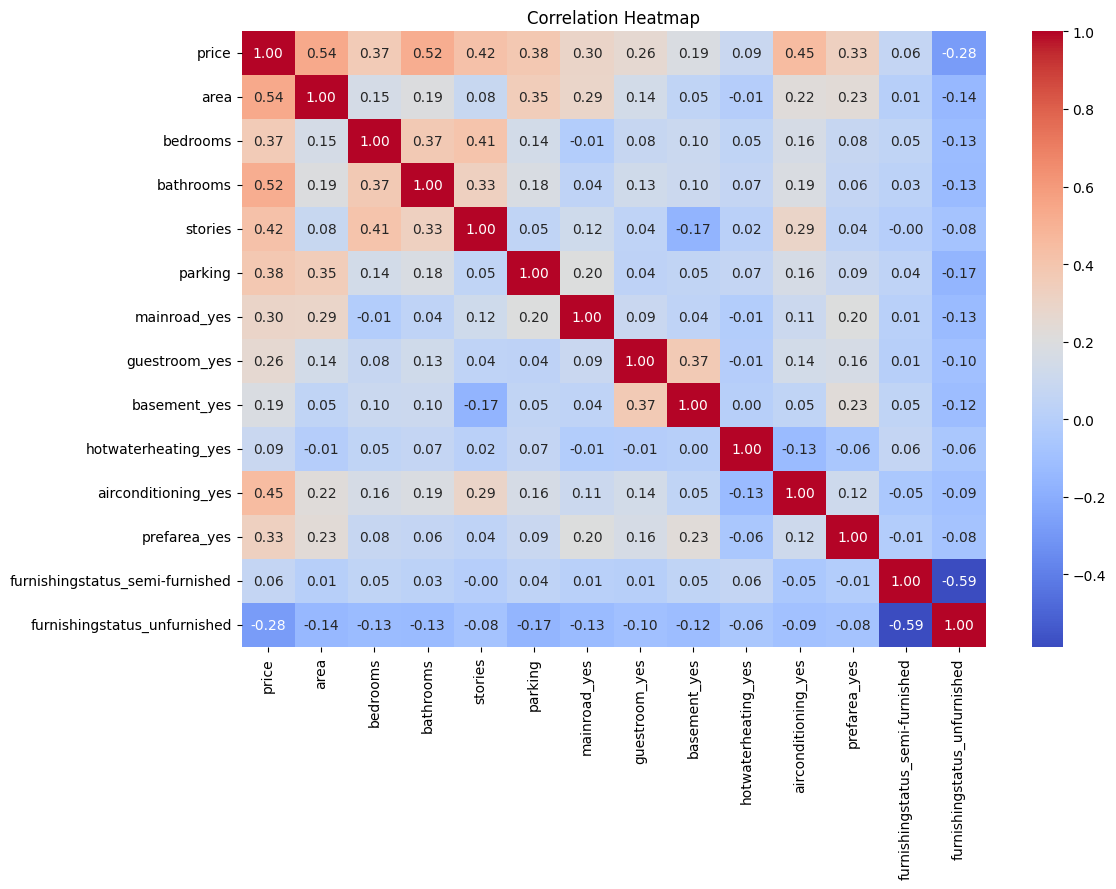

In [33]:
plt.figure(figsize=(12,8))

correlation_matrix = df_encoded.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

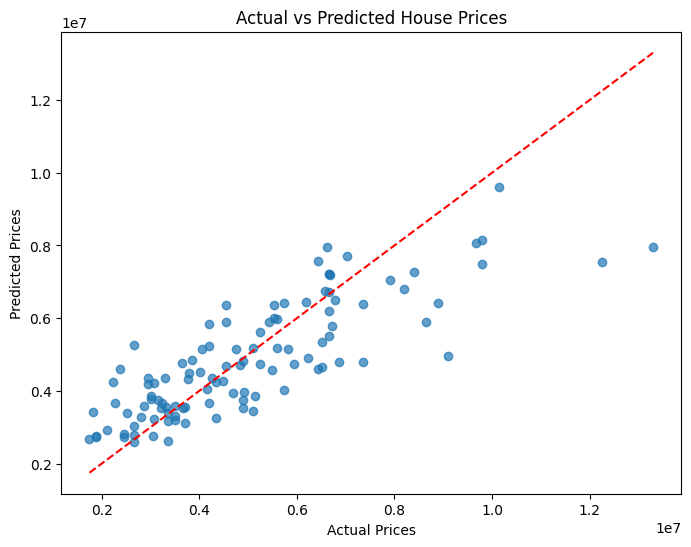

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.7
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

                Feature   Coefficient
2             bathrooms  1.094445e+06
9   airconditioning_yes  7.914267e+05
8   hotwaterheating_yes  6.846499e+05
10         prefarea_yes  6.298906e+05
3               stories  4.074766e+05
7          basement_yes  3.902512e+05
5          mainroad_yes  3.679199e+05
6         guestroom_yes  2.316100e+05
4               parking  2.248419e+05
1              bedrooms  7.677870e+04


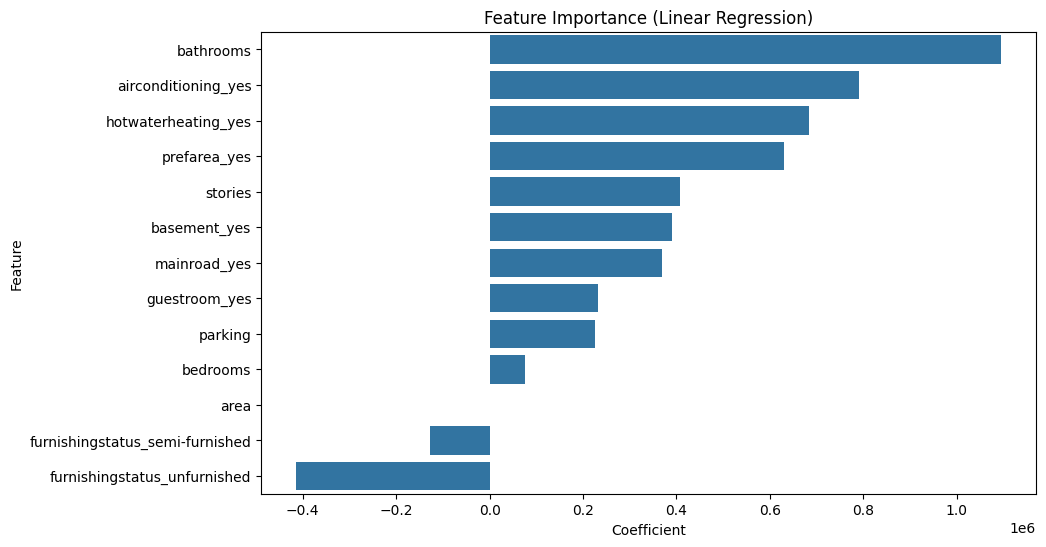

In [36]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients
)
print(coefficients.head(10))

plt.title('Feature Importance (Linear Regression)')
plt.show()

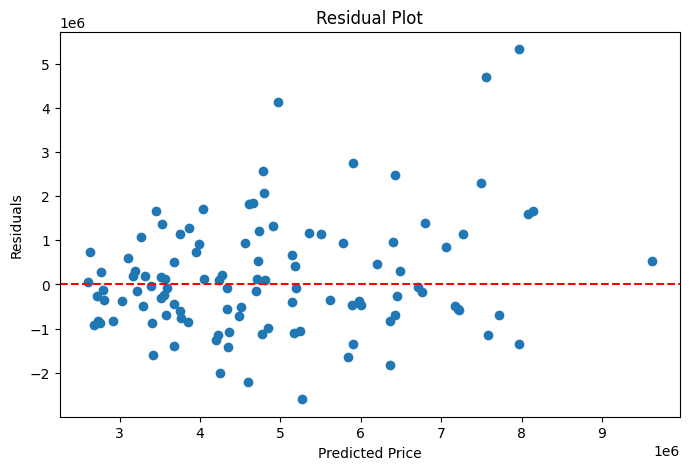

In [37]:
residuals = y_test - lr_predictions

plt.figure(figsize=(8,5))
plt.scatter(lr_predictions, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Conclusion

- Data was successfully cleaned and prepared.
- Two machine learning models were trained.
- Linear Regression achieved the best performance.

Results:
- MAE = 970,043
- RMSE = 1,324,507
- R² = 0.653

The model can reasonably predict house prices based on available housing features.

In [38]:
import joblib

joblib.dump(lr_model, "house_price_model.pkl")

['house_price_model.pkl']

The best-performing model was saved for future deployment.

TASK5:INSIGHTS & SUMMARY


In this project, I found that features like area, number of bathrooms, stories, parking spaces and air conditioning have the biggest effect on house prices. The Linear Regression model performed better than the Random Forest model and achieved an R² score of about 0.65. This means the model was able to predict house prices with reasonable accuracy using the available features. One thing that surprised me was that the simpler Linear Regression model gave better results than the Random Forest model. I also noticed that larger houses with more facilities generally had higher prices. Based on these findings, I would recommend that real estate businesses focus on properties with good amenities and larger areas, as these factors increase the value of a house.
